# 03 — Recommendation Logic & Purchasing Trends
**Big Data Programming — Assignment 01 | Use Case 3: E-Commerce Recommendation System**  
**Developer:** Kevin | **Dataset:** Brazilian E-Commerce (Olist) — `cleaned_data_full.csv`

---
**Part A — Recommendation Logic:** Hybrid recommender (co-purchase + sequential affinity + popularity fallback)  
**Part B — Purchasing Trends:** Monthly/yearly sales trends by product category  
Design patterns demonstrated: **Join · Aggregation · Filtering · Sorting**

## 0. Environment Setup

In [11]:
# !pip install pyspark --quiet

In [12]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import StringType

spark = SparkSession.builder \
    .appName("Ecommerce_Recommendations_Trends") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")
os.makedirs("output", exist_ok=True)
print(f"Spark {spark.version} ready.")

Spark 4.1.1 ready.


## 1. Load Dataset


In [13]:
# load cleaned dataset directly from HDFS Parquet
DATA_PATH = "hdfs://localhost:8020/ecommerce/output/cleaned_data"

df = spark.read.parquet(DATA_PATH)

print(f"Rows    : {df.count():,}")
print(f"Columns : {len(df.columns)}")

df.select(
    "order_id", "customer_unique_id", "product_id",
    "product_category_name", "price",
    "purchase_year", "purchase_month"
).show(5, truncate=40)

Rows    : 101,953
Columns : 41
+--------------------------------+--------------------------------+--------------------------------+---------------------+-----+-------------+--------------+
|                        order_id|              customer_unique_id|                      product_id|product_category_name|price|purchase_year|purchase_month|
+--------------------------------+--------------------------------+--------------------------------+---------------------+-----+-------------+--------------+
|0006ec9db01a64e59a68b2c340bf65a7|7ed0ea20347f67fe61d1c99fdf8556ae|99a4788cb24856965c36a24e339b6058|      cama_mesa_banho| 74.0|         2018|             7|
|000e63d38ae8c00bbcb5a30573b99628|860fc00d3154ce2346c43ebe47b9b6ce|553e0e7590d3116a072507a3635d2877|      cama_mesa_banho| 47.9|         2018|             3|
|00169e31ef4b29deaae414f9a5e95929|577edb526f98771b20d6db4a51d79423|b10eba910a974df70b8a12d0665cdb9e|      cama_mesa_banho| 39.0|         2018|             1|
|00337fe25a3780b3424d

In [14]:
df.select('order_status').distinct().show()

+------------+
|order_status|
+------------+
|     shipped|
|    invoiced|
|   delivered|
|  processing|
|    approved|
+------------+



We are filtering for only 'delivered' orders because these represent completed transactions where the customer successfully received the product. For building a recommendation system and analyzing purchasing trends, it's crucial to focus on actual, successful purchases. Orders that are 'shipped', 'approved', 'invoiced', or 'processing' are still in transit or have not yet been finalized, and might be cancelled or returned.

In [15]:
category_counts_per_order = df.groupBy("order_id").agg(F.countDistinct("product_category_name").alias("category_count"))
total_orders = category_counts_per_order.count()
orders_with_one_category = category_counts_per_order.filter(F.col("category_count") == 1).count()
percentage_one_category = (orders_with_one_category / total_orders) * 100
print(f"Percentage of orders with only one product category: {percentage_one_category:.2f}%")

Percentage of orders with only one product category: 99.20%


## 2. Data Preparation
Keep delivered orders, remove nulls, normalise category strings, drop the `unknown` category that pollutes co-purchase pairs.

In [16]:
df_clean = df.filter(F.col("order_status") == "delivered") \
    .dropna(subset=["order_id","customer_unique_id","product_id","product_category_name"]) \
    .withColumn("category", F.trim(F.lower(F.col("product_category_name")))) \
    .filter(F.col("category") != "unknown")   # remove dirty category

df_clean.cache()
print(f"Delivered rows : {df_clean.count():,}")
print(f"Distinct customers : {df_clean.select('customer_unique_id').distinct().count():,}")
print(f"Distinct orders    : {df_clean.select('order_id').distinct().count():,}")
print(f"Distinct categories: {df_clean.select('category').distinct().count():,}")

26/04/24 22:13:15 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Delivered rows : 98,795
Distinct customers : 92,098
Distinct orders    : 95,146
Distinct categories: 73


# Part A — Recommendation Logic

## Why a Hybrid Approach?

Most of the data is sparse:
- ~99% of orders contain only one product category  
- ~99% of customers have placed only one order  

As a result, relying only on co-purchase patterns would cover less than 1% of cases and fail to generate meaningful recommendations for most customers.

To address this, we use a hybrid approach that combines multiple signals.

---

## Signals Used

### 1. Co-purchase (Primary Signal)
- Based on products bought together in the same order  
- Example: Customers who buy shampoo also buy conditioner  
- This is the strongest and most reliable signal when available  

### 2. Sequential Affinity (Secondary Signal)
- Based on categories purchased by repeat customers over time  
- Example: A customer buys protein powder, then later buys a shaker bottle  
- Captures longer-term customer preferences  

### 3. Popularity (Fallback Signal)
- Based on overall demand across all customers  
- Example: Best-selling product categories  
- Ensures recommendations are available even for new or one-time customers  

---

## Weighting Strategy

- Co-purchase signal is given the highest priority (2× weight)  
- Sequential affinity is used as a secondary signal  
- Popularity is used as a fallback or tie-breaker  


In [17]:
category_counts_per_order = df_clean.groupBy("order_id").agg(F.countDistinct("category").alias("category_count"))

total_orders = category_counts_per_order.count()
orders_with_one_category = category_counts_per_order.filter(F.col("category_count") == 1).count()

percentage_one_category = (orders_with_one_category / total_orders) * 100

print(f"Total distinct orders: {total_orders:,}")
print(f"Orders with only one product category: {orders_with_one_category:,}")
print(f"Percentage of orders with only one product category: {percentage_one_category:.2f}%")

Total distinct orders: 95,146
Orders with only one product category: 94,423
Percentage of orders with only one product category: 99.24%


### A1. Co-Purchase Signal
Self-join on `order_id` to find category pairs in the same basket.

In [18]:
order_cat = df_clean.select("order_id", "category").distinct()

left  = order_cat.alias("L")
right = order_cat.alias("R")

# Only keep pairs where L.category < R.category to avoid (A,B)+(B,A) duplicates
co_purchase_raw = left.join(right, on="order_id") \
    .filter(F.col("L.category") < F.col("R.category")) \
    .groupBy(F.col("L.category").alias("cat_a"), F.col("R.category").alias("cat_b")) \
    .agg(F.count("*").alias("co_count"))

# Make bidirectional so any category a customer bought can look up partners
co_signal = co_purchase_raw.select(F.col("cat_a").alias("from_cat"), F.col("cat_b").alias("to_cat"), "co_count") \
    .union(co_purchase_raw.select(F.col("cat_b").alias("from_cat"), F.col("cat_a").alias("to_cat"), "co_count"))

print(f"Co-purchase pairs (bidirectional): {co_signal.count():,}")
co_purchase_raw.orderBy(F.desc("co_count")).show(10, truncate=50)

Co-purchase pairs (bidirectional): 484
+------------------+---------------------+--------+
|             cat_a|                cat_b|co_count|
+------------------+---------------------+--------+
|   cama_mesa_banho|     moveis_decoracao|      70|
|   cama_mesa_banho|        casa_conforto|      43|
|  moveis_decoracao|utilidades_domesticas|      24|
|             bebes|           cool_stuff|      20|
|   cama_mesa_banho|utilidades_domesticas|      20|
|             bebes|           brinquedos|      19|
|             bebes|      cama_mesa_banho|      17|
|ferramentas_jardim|     moveis_decoracao|      16|
|      beleza_saude|        esporte_lazer|      14|
|   casa_construcao|     moveis_decoracao|      13|
+------------------+---------------------+--------+
only showing top 10 rows


### A2. Sequential Affinity Signal
For customers with more than one order, find which categories they bought across different orders. This captures longer-term preference patterns that a single-basket signal misses.

In [19]:
# Customers who placed more than one order
orders_per_cust = df_clean.select("customer_unique_id","order_id").distinct() \
    .groupBy("customer_unique_id").agg(F.count("order_id").alias("order_count"))

repeat_custs = orders_per_cust.filter(F.col("order_count") > 1).select("customer_unique_id")

# All (customer, category) pairs for repeat customers
repeat_history = df_clean.join(repeat_custs, on="customer_unique_id") \
    .select("customer_unique_id", "category").distinct()

# Self-join to get all (from_cat, to_cat) pairs within the same customer's history
h_left  = repeat_history.alias("HL")
h_right = repeat_history.alias("HR")

seq_signal = h_left.join(h_right, on="customer_unique_id") \
    .filter(F.col("HL.category") != F.col("HR.category")) \
    .groupBy(F.col("HL.category").alias("from_cat"), F.col("HR.category").alias("to_cat")) \
    .agg(F.count("*").alias("seq_count"))

print(f"Repeat customers: {repeat_custs.count():,}")
print(f"Sequential affinity pairs: {seq_signal.count():,}")
seq_signal.orderBy(F.desc("seq_count")).show(10, truncate=50)

Repeat customers: 2,742
Sequential affinity pairs: 984
+---------------------+---------------------+---------+
|             from_cat|               to_cat|seq_count|
+---------------------+---------------------+---------+
|     moveis_decoracao|      cama_mesa_banho|       97|
|      cama_mesa_banho|     moveis_decoracao|       97|
|utilidades_domesticas|      cama_mesa_banho|       50|
|      cama_mesa_banho|utilidades_domesticas|       50|
|utilidades_domesticas|     moveis_decoracao|       39|
|     moveis_decoracao|utilidades_domesticas|       39|
|   ferramentas_jardim|     moveis_decoracao|       29|
|     moveis_decoracao|   ferramentas_jardim|       29|
|        esporte_lazer|         beleza_saude|       26|
|         beleza_saude|        esporte_lazer|       26|
+---------------------+---------------------+---------+
only showing top 10 rows


### A3. Popularity Baseline
Global order frequency per category — used as a small tie-breaker for customers with no matching affinity signal (cold-start).

In [20]:
cat_popularity = df_clean.select("order_id","category").distinct() \
    .groupBy("category") \
    .agg(F.count("order_id").alias("pop_count"))

# Normalise 0–1 so it blends proportionally into final score
max_pop = cat_popularity.agg(F.max("pop_count")).collect()[0][0]
cat_popularity = cat_popularity.withColumn("pop_score", F.round(F.col("pop_count") / max_pop, 4))

print("Top 10 popular categories:")
cat_popularity.orderBy(F.desc("pop_count")).show(10, truncate=50)

Top 10 popular categories:
+----------------------+---------+---------+
|              category|pop_count|pop_score|
+----------------------+---------+---------+
|       cama_mesa_banho|     9272|      1.0|
|          beleza_saude|     8647|   0.9326|
|         esporte_lazer|     7530|   0.8121|
|informatica_acessorios|     6530|   0.7043|
|      moveis_decoracao|     6307|   0.6802|
| utilidades_domesticas|     5743|   0.6194|
|    relogios_presentes|     5495|   0.5926|
|             telefonia|     4093|   0.4414|
|            automotivo|     3810|   0.4109|
|            brinquedos|     3804|   0.4103|
+----------------------+---------+---------+
only showing top 10 rows


### A4. Merge Signals into a Combined Affinity Table
Co-purchase weighted 2× (strongest, in-basket signal); sequential 1×; popularity added as a small boost.

In [21]:
# Combine co-purchase and sequential on (from_cat, to_cat)
combined_affinity = co_signal.join(seq_signal, on=["from_cat","to_cat"], how="outer") \
    .na.fill(0) \
    .withColumn("affinity_score", F.col("co_count") * 2 + F.col("seq_count"))

# Attach popularity of the target category
combined_affinity = combined_affinity.join(
    cat_popularity.select(F.col("category").alias("to_cat"), "pop_score"),
    on="to_cat", how="left"
).na.fill({"pop_score": 0})

print(f"Combined affinity table rows: {combined_affinity.count():,}")
combined_affinity.orderBy(F.desc("affinity_score")).show(10, truncate=50)

Combined affinity table rows: 1,094


+---------------------+---------------------+--------+---------+--------------+---------+
|               to_cat|             from_cat|co_count|seq_count|affinity_score|pop_score|
+---------------------+---------------------+--------+---------+--------------+---------+
|     moveis_decoracao|      cama_mesa_banho|      70|       97|           237|   0.6802|
|      cama_mesa_banho|     moveis_decoracao|      70|       97|           237|      1.0|
|        casa_conforto|      cama_mesa_banho|      43|       16|           102|   0.0423|
|      cama_mesa_banho|        casa_conforto|      43|       16|           102|      1.0|
|utilidades_domesticas|      cama_mesa_banho|      20|       50|            90|   0.6194|
|      cama_mesa_banho|utilidades_domesticas|      20|       50|            90|      1.0|
|utilidades_domesticas|     moveis_decoracao|      24|       39|            87|   0.6194|
|     moveis_decoracao|utilidades_domesticas|      24|       39|            87|   0.6802|
|     move

### A5. Build Customer Purchase History

In [22]:
customer_history = df_clean.select("customer_unique_id","category").distinct()
print(f"Customer-category pairs: {customer_history.count():,}")
customer_history.show(8, truncate=50)

Customer-category pairs: 94,403
+--------------------------------+------------------+
|              customer_unique_id|          category|
+--------------------------------+------------------+
|5126a6c336684b39a9006bad4b60f9e1|  malas_acessorios|
|d0b5b4d23c6d9a316527adec08991173|ferramentas_jardim|
|d1bc2e7c514ea94310b532b08a24c892|         papelaria|
|6e9d7c002cb4603011d3e83033b01878|relogios_presentes|
|3e96d96e52761d91cdbd5c5c48392ba6|relogios_presentes|
|75d0154ed5d24c347fd4c5bccc050e1c|relogios_presentes|
|b22cae625b7fd16cb107b13c4a4e9ca0|ferramentas_jardim|
|e7b35481f69de0c49f87fddcdf4dc273|         papelaria|
+--------------------------------+------------------+
only showing top 8 rows


### A6. Generate & Score Candidate Recommendations
For each customer, join their purchased categories against the affinity table, then sum affinity scores for the same target category.

In [23]:
# Join: each category a customer bought → look up what it pairs with
candidates = customer_history.join(
    combined_affinity,
    customer_history["category"] == combined_affinity["from_cat"],
    how="inner"
).select(
    "customer_unique_id",
    "to_cat",
    "affinity_score",
    "pop_score"
)

# Sum affinity across all source categories pointing to the same target
scored = candidates.groupBy("customer_unique_id","to_cat").agg(
    F.sum("affinity_score").alias("total_affinity"),
    F.max("pop_score").alias("pop_score")
).withColumn(
    "final_score",
    F.round(F.col("total_affinity") + F.col("pop_score") * 5, 4)
)

print(f"Scored candidate rows: {scored.count():,}")

Scored candidate rows: 3,236,862


### A7. Filter Already-Purchased Categories & Rank Top 5

In [24]:
# Anti-join: drop (customer, to_cat) pairs where customer already bought to_cat
already_bought = customer_history.select(
    F.col("customer_unique_id").alias("c_id"),
    F.col("category").alias("owned")
)

new_recs = scored.join(
    already_bought,
    (scored["customer_unique_id"] == already_bought["c_id"]) &
    (scored["to_cat"] == already_bought["owned"]),
    how="left_anti"
)

# Rank within each customer, keep top 5
window_rank = Window.partitionBy("customer_unique_id").orderBy(F.desc("final_score"))
top5 = new_recs.withColumn("rank", F.rank().over(window_rank)).filter(F.col("rank") <= 5)

print(f"Customers with recommendations: {top5.select('customer_unique_id').distinct().count():,}")
print(f"Total recommendation rows    : {top5.count():,}")
top5.orderBy("customer_unique_id","rank").show(20, truncate=50)

Customers with recommendations: 92,047


Total recommendation rows    : 458,318


+--------------------------------+----------------------+--------------+---------+-----------+----+
|              customer_unique_id|                to_cat|total_affinity|pop_score|final_score|rank|
+--------------------------------+----------------------+--------------+---------+-----------+----+
|0000366f3b9a7992bf8c76cfdf3221e2|      moveis_decoracao|           237|   0.6802|    240.401|   1|
|0000366f3b9a7992bf8c76cfdf3221e2|         casa_conforto|           102|   0.0423|   102.2115|   2|
|0000366f3b9a7992bf8c76cfdf3221e2| utilidades_domesticas|            90|   0.6194|     93.097|   3|
|0000366f3b9a7992bf8c76cfdf3221e2|                 bebes|            56|    0.303|     57.515|   4|
|0000366f3b9a7992bf8c76cfdf3221e2|          beleza_saude|            40|   0.9326|     44.663|   5|
|0000b849f77a49e4a4ce2b2a4ca5be3f|         esporte_lazer|            54|   0.8121|    58.0605|   1|
|0000b849f77a49e4a4ce2b2a4ca5be3f|       cama_mesa_banho|            40|      1.0|       45.0|   2|


### A8. Validate — Show Sample Recommendations vs Purchase History

In [25]:
sample_custs = top5.select("customer_unique_id").distinct().limit(10)

print("── Purchase history (10 sample customers) ──")
customer_history.join(sample_custs, on="customer_unique_id") \
    .groupBy("customer_unique_id") \
    .agg(F.collect_list("category").alias("purchased")) \
    .orderBy("customer_unique_id").show(10, truncate=80)

print("── Recommendations ──")
top5.join(sample_custs, on="customer_unique_id") \
    .select("customer_unique_id","rank","to_cat","final_score") \
    .orderBy("customer_unique_id","rank").show(50, truncate=50)

── Purchase history (10 sample customers) ──


+--------------------------------+------------------------------+
|              customer_unique_id|                     purchased|
+--------------------------------+------------------------------+
|0006fdc98a402fceb4eb0ee528f6a8d4|             [cama_mesa_banho]|
|00090324bbad0e9342388303bb71ba0a|             [cama_mesa_banho]|
|000c8bdb58a29e7115cfc257230fb21b|             [cama_mesa_banho]|
|00115fc7123b5310cf6d3a3aa932699e|               [esporte_lazer]|
|001f3c4211216384d5fe59b041ce1461|       [utilidades_domesticas]|
|0023557a94bef0038066b5d1b3dc763e|                  [automotivo]|
|003800162424b7b5b3d75c9cf22a66e7|          [ferramentas_jardim]|
|00391594070baf8603f5fdc1d0c6a48c|      [informatica_acessorios]|
|004288347e5e88a27ded2bb23747066c|[cool_stuff, malas_acessorios]|
|0042dfa8925d6eb23e471ec350454f04|                       [bebes]|
+--------------------------------+------------------------------+

── Recommendations ──


+--------------------------------+----+----------------------+-----------+
|              customer_unique_id|rank|                to_cat|final_score|
+--------------------------------+----+----------------------+-----------+
|0006fdc98a402fceb4eb0ee528f6a8d4|   1|      moveis_decoracao|    240.401|
|0006fdc98a402fceb4eb0ee528f6a8d4|   2|         casa_conforto|   102.2115|
|0006fdc98a402fceb4eb0ee528f6a8d4|   3| utilidades_domesticas|     93.097|
|0006fdc98a402fceb4eb0ee528f6a8d4|   4|                 bebes|     57.515|
|0006fdc98a402fceb4eb0ee528f6a8d4|   5|          beleza_saude|     44.663|
|00090324bbad0e9342388303bb71ba0a|   1|      moveis_decoracao|    240.401|
|00090324bbad0e9342388303bb71ba0a|   2|         casa_conforto|   102.2115|
|00090324bbad0e9342388303bb71ba0a|   3| utilidades_domesticas|     93.097|
|00090324bbad0e9342388303bb71ba0a|   4|                 bebes|     57.515|
|00090324bbad0e9342388303bb71ba0a|   5|          beleza_saude|     44.663|
|000c8bdb58a29e7115cfc257

### A9. Save Recommendation Outputs

In [26]:
top5.select("customer_unique_id","rank",
            F.col("to_cat").alias("recommended_category"), "final_score") \
    .orderBy("customer_unique_id","rank") \
    .coalesce(1).write.csv("output/recommendations", header=True, mode="overwrite")

co_purchase_raw.orderBy(F.desc("co_count")) \
    .coalesce(1).write.csv("output/co_purchase_matrix", header=True, mode="overwrite")

print("Saved: output/recommendations/  |  output/co_purchase_matrix/")

Saved: output/recommendations/  |  output/co_purchase_matrix/


---
# Part B — Purchasing Trends Analysis
Analyses:
- **B1** Monthly order volume over time (overall trend)
- **B2** Top 10 best-selling categories
- **B3** Category-level monthly trends (heatmap)
- **B4** Year-over-year growth by category
- **B5** Day-of-week and hour-of-day purchasing patterns

### B1. Monthly Order Volume — Overall Trend

In [27]:
monthly_orders = df_clean.select("order_id","purchase_year","purchase_month").distinct() \
    .groupBy("purchase_year","purchase_month") \
    .agg(F.count("order_id").alias("total_orders")) \
    .withColumn("year_month", F.concat(
        F.col("purchase_year").cast(StringType()), F.lit("-"),
        F.lpad(F.col("purchase_month").cast(StringType()), 2, "0")
    )).orderBy("purchase_year","purchase_month")

monthly_orders.select("year_month","total_orders").show(40)

+----------+------------+
|year_month|total_orders|
+----------+------------+
|   2016-09|           1|
|   2016-10|         263|
|   2016-12|           1|
|   2017-01|         740|
|   2017-02|        1603|
|   2017-03|        2496|
|   2017-04|        2243|
|   2017-05|        3467|
|   2017-06|        3085|
|   2017-07|        3824|
|   2017-08|        4129|
|   2017-09|        4091|
|   2017-10|        4428|
|   2017-11|        7187|
|   2017-12|        5383|
|   2018-01|        6901|
|   2018-02|        6450|
|   2018-03|        6884|
|   2018-04|        6731|
|   2018-05|        6716|
|   2018-06|        6078|
|   2018-07|        6121|
|   2018-08|        6324|
+----------+------------+



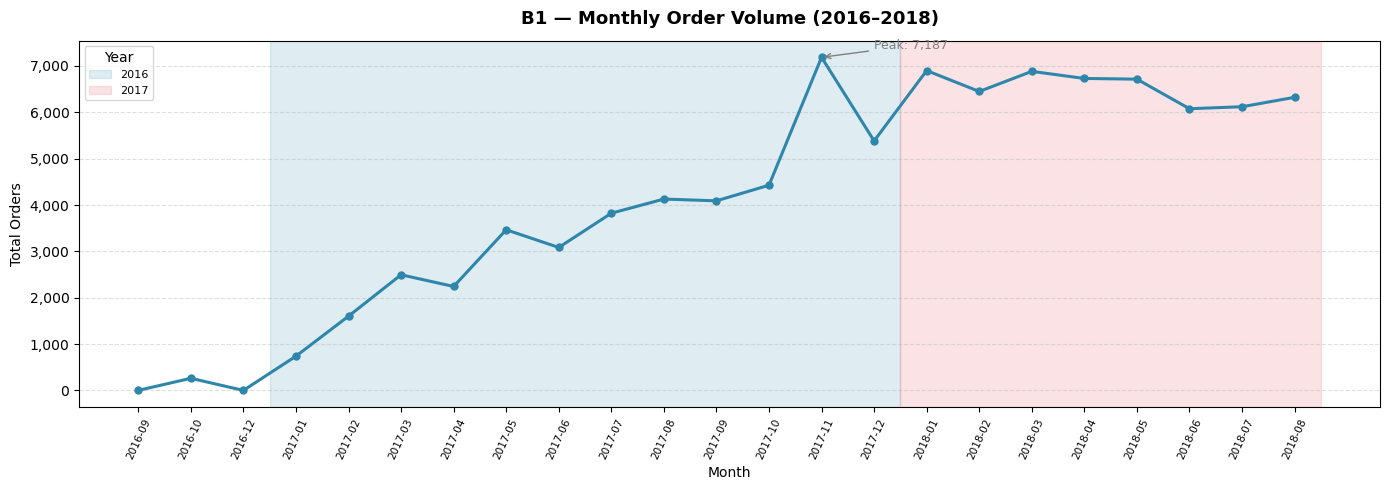

In [28]:
monthly_pd = monthly_orders.select("year_month","total_orders").toPandas() \
    .sort_values("year_month").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_pd["year_month"], monthly_pd["total_orders"],
        marker="o", linewidth=2.2, color="#2E86AB", markersize=5)

year_starts = [i for i, ym in enumerate(monthly_pd["year_month"]) if ym.endswith("-01")]
for idx, start in enumerate(year_starts):
    end = year_starts[idx+1] if idx+1 < len(year_starts) else len(monthly_pd)
    ax.axvspan(start-.5, end-.5, alpha=0.15, color=["#2E86AB","#E84855","#2E86AB"][idx],
               label=["2016","2017","2018"][idx])

peak_idx = monthly_pd["total_orders"].idxmax()
ax.annotate(f"Peak: {monthly_pd.loc[peak_idx,'total_orders']:,}",
    xy=(peak_idx, monthly_pd.loc[peak_idx,"total_orders"]),
    xytext=(peak_idx+1, monthly_pd.loc[peak_idx,"total_orders"]+180),
    arrowprops=dict(arrowstyle="->", color="gray"), fontsize=9, color="gray")

ax.set_title("B1 — Monthly Order Volume (2016–2018)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Month"); ax.set_ylabel("Total Orders")
ax.tick_params(axis="x", rotation=65, labelsize=7.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
ax.legend(title="Year", fontsize=8); ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("output/B1_monthly_order_trend.png", dpi=150, bbox_inches="tight"); plt.show()

### B2. Top 10 Best-Selling Categories Overall

In [29]:
top_categories = df_clean.select("order_id","category").distinct() \
    .groupBy("category").agg(F.count("order_id").alias("total_orders")) \
    .orderBy(F.desc("total_orders")).limit(10)

top_categories.show(truncate=50)

+----------------------+------------+
|              category|total_orders|
+----------------------+------------+
|       cama_mesa_banho|        9272|
|          beleza_saude|        8647|
|         esporte_lazer|        7530|
|informatica_acessorios|        6530|
|      moveis_decoracao|        6307|
| utilidades_domesticas|        5743|
|    relogios_presentes|        5495|
|             telefonia|        4093|
|            automotivo|        3810|
|            brinquedos|        3804|
+----------------------+------------+



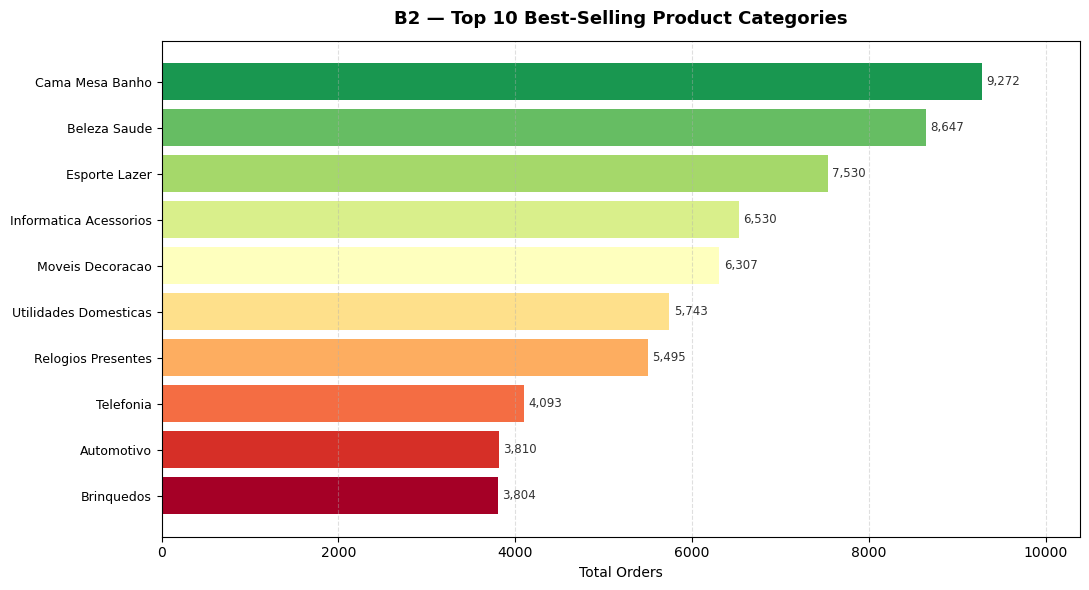

In [30]:
top_cats_pd = top_categories.toPandas().sort_values("total_orders", ascending=True)
top_cats_pd["label"] = top_cats_pd["category"].str.replace("_"," ").str.title()

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_cats_pd["label"], top_cats_pd["total_orders"],
               color=plt.cm.RdYlGn([i/len(top_cats_pd) for i in range(len(top_cats_pd))]))
for bar in bars:
    ax.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2,
            f"{int(bar.get_width()):,}", va="center", fontsize=8.5, color="#333")

ax.set_title("B2 — Top 10 Best-Selling Product Categories", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Total Orders"); ax.set_xlim(0, top_cats_pd["total_orders"].max()*1.12)
ax.tick_params(axis="y", labelsize=9); ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("output/B2_top_categories.png", dpi=150, bbox_inches="tight"); plt.show()

### B3. Category-Level Monthly Trends

In [31]:
monthly_category_trend = df_clean \
    .select("order_id","purchase_year","purchase_month","category").distinct() \
    .groupBy("purchase_year","purchase_month","category") \
    .agg(F.count("order_id").alias("order_count")) \
    .withColumn("year_month", F.concat(
        F.col("purchase_year").cast(StringType()), F.lit("-"),
        F.lpad(F.col("purchase_month").cast(StringType()), 2, "0")
    )).orderBy("purchase_year","purchase_month", F.desc("order_count"))

# Top category per month via Window rank
window_monthly = Window.partitionBy("year_month").orderBy(F.desc("order_count"))
monthly_category_trend.withColumn("rank", F.rank().over(window_monthly)) \
    .filter(F.col("rank") == 1) \
    .select("year_month","category","order_count") \
    .orderBy("year_month").show(40, truncate=50)

+----------+---------------------------+-----------+
|year_month|                   category|order_count|
+----------+---------------------------+-----------+
|   2016-09|               beleza_saude|          1|
|   2016-10|           moveis_decoracao|         49|
|   2016-12|fashion_bolsas_e_acessorios|          1|
|   2017-01|           moveis_decoracao|        132|
|   2017-02|           moveis_decoracao|        213|
|   2017-03|           moveis_decoracao|        253|
|   2017-04|            cama_mesa_banho|        231|
|   2017-05|            cama_mesa_banho|        323|
|   2017-06|            cama_mesa_banho|        324|
|   2017-07|            cama_mesa_banho|        503|
|   2017-08|            cama_mesa_banho|        442|
|   2017-09|            cama_mesa_banho|        456|
|   2017-10|            cama_mesa_banho|        442|
|   2017-11|            cama_mesa_banho|        804|
|   2017-12|            cama_mesa_banho|        476|
|   2018-01|            cama_mesa_banho|      

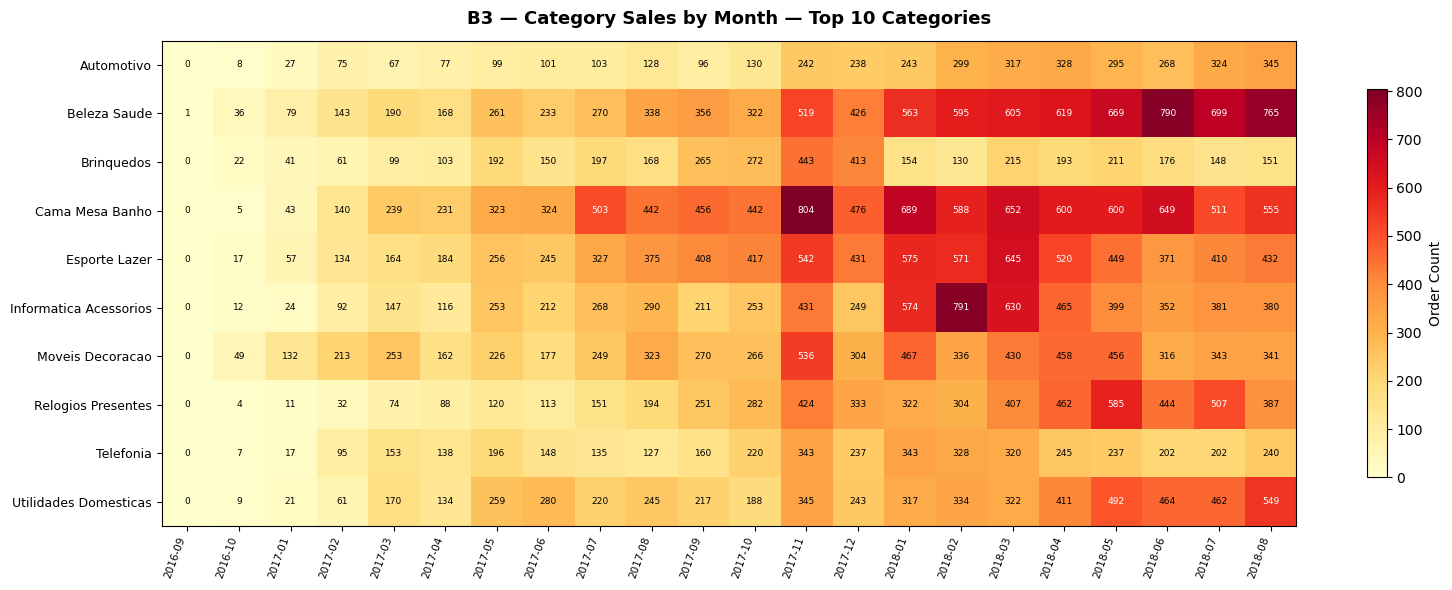

In [32]:
mct_pd = monthly_category_trend.select("year_month","category","order_count").toPandas()
top10_cats = mct_pd.groupby("category")["order_count"].sum() \
    .sort_values(ascending=False).head(10).index.tolist()

heatmap_df = mct_pd[mct_pd["category"].isin(top10_cats)].pivot_table(
    index="category", columns="year_month", values="order_count", fill_value=0)
heatmap_df = heatmap_df[sorted(heatmap_df.columns)]
heatmap_df.index = heatmap_df.index.str.replace("_"," ").str.title()

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(heatmap_df.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=70, ha="right", fontsize=7.5)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index, fontsize=9)
threshold = heatmap_df.values.max() * 0.6
for i in range(len(heatmap_df.index)):
    for j in range(len(heatmap_df.columns)):
        val = int(heatmap_df.values[i,j])
        ax.text(j, i, str(val), ha="center", va="center",
                fontsize=6.5, color="white" if val > threshold else "black")
plt.colorbar(im, ax=ax, label="Order Count", shrink=0.8)
ax.set_title("B3 — Category Sales by Month — Top 10 Categories", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("output/B3_category_monthly_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

### B4. Year-over-Year Growth by Category
2016 data is sparse (Olist launched late 2016) so the 2016→2017 chart is shown separately with a note. The 2017→2018 comparison is the reliable growth view.

In [33]:
# Pivot: one column per year — use conditional aggregation to avoid column type ambiguity
annual_category = df_clean.select("order_id","purchase_year","category").distinct() \
    .groupBy("category") \
    .agg(
        F.sum(F.when(F.col("purchase_year")==2016, 1).otherwise(0)).alias("orders_2016"),
        F.sum(F.when(F.col("purchase_year")==2017, 1).otherwise(0)).alias("orders_2017"),
        F.sum(F.when(F.col("purchase_year")==2018, 1).otherwise(0)).alias("orders_2018")
    ) \
    .withColumn("growth_16_17_pct",
        F.when(F.col("orders_2016") > 0,
            F.round((F.col("orders_2017")-F.col("orders_2016"))/F.col("orders_2016")*100, 1))
        .otherwise(None)) \
    .withColumn("growth_17_18_pct",
        F.when(F.col("orders_2017") > 0,
            F.round((F.col("orders_2018")-F.col("orders_2017"))/F.col("orders_2017")*100, 1))
        .otherwise(None)) \
    .orderBy(F.desc("orders_2017"))

print("Year-over-year growth (top 20 by 2017 volume):")
annual_category.show(20, truncate=45)

Year-over-year growth (top 20 by 2017 volume):
+---------------------------+-----------+-----------+-----------+----------------+----------------+
|                   category|orders_2016|orders_2017|orders_2018|growth_16_17_pct|growth_17_18_pct|
+---------------------------+-----------+-----------+-----------+----------------+----------------+
|            cama_mesa_banho|          5|       4423|       4844|         88360.0|             9.5|
|              esporte_lazer|         17|       3540|       3973|         20723.5|            12.2|
|               beleza_saude|         37|       3305|       5305|          8832.4|            60.5|
|           moveis_decoracao|         49|       3111|       3147|          6249.0|             1.2|
|     informatica_acessorios|         12|       2546|       3972|         21116.7|            56.0|
|                 brinquedos|         22|       2404|       1378|         10827.3|           -42.7|
|      utilidades_domesticas|          9|       2383|

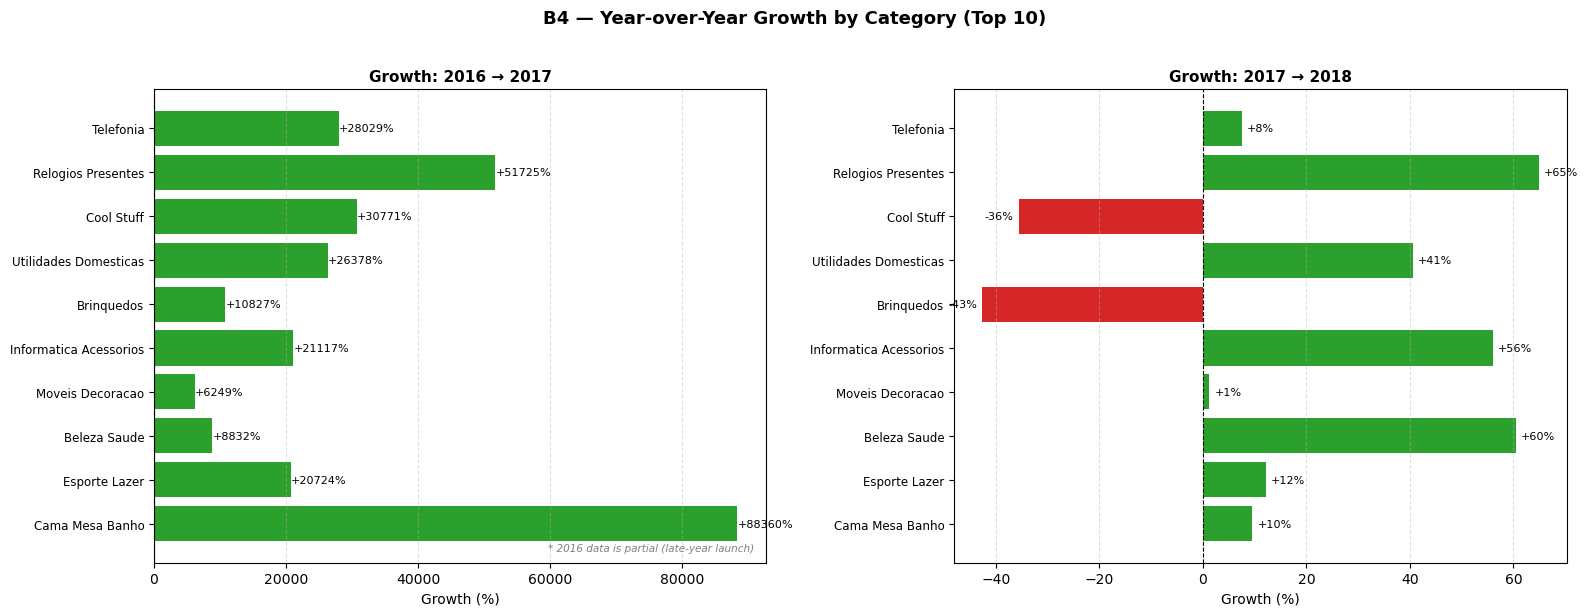

In [34]:
yoy_pd = annual_category.toPandas()
yoy_pd["label"] = yoy_pd["category"].str.replace("_"," ").str.title()

# Left chart: 2016→2017 (only categories that existed in 2016)
yoy_16 = yoy_pd[yoy_pd["growth_16_17_pct"].notna()].nlargest(10,"orders_2017")
# Right chart: 2017→2018 (all 2017 categories)
yoy_17 = yoy_pd[yoy_pd["growth_17_18_pct"].notna()].nlargest(10,"orders_2017")

def bar_colors(vals): return ["#2ca02c" if v >= 0 else "#d62728" for v in vals]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
b1 = ax1.barh(yoy_16["label"], yoy_16["growth_16_17_pct"], color=bar_colors(yoy_16["growth_16_17_pct"]))
ax1.axvline(0, color="black", linewidth=0.8, linestyle="--")
for bar in b1:
    w = bar.get_width()
    ax1.text(w+(5 if w>=0 else -5), bar.get_y()+bar.get_height()/2,
             f"{w:+.0f}%", va="center", ha="left" if w>=0 else "right", fontsize=8)
ax1.set_title("Growth: 2016 → 2017", fontsize=11, fontweight="bold")
ax1.set_xlabel("Growth (%)")
ax1.tick_params(axis="y", labelsize=8.5)
ax1.grid(axis="x", linestyle="--", alpha=0.4)
ax1.text(0.98, 0.02, "* 2016 data is partial (late-year launch)",
         transform=ax1.transAxes, fontsize=7.5, color="gray", ha="right", va="bottom", style="italic")

ax2 = axes[1]
b2 = ax2.barh(yoy_17["label"], yoy_17["growth_17_18_pct"], color=bar_colors(yoy_17["growth_17_18_pct"]))
ax2.axvline(0, color="black", linewidth=0.8, linestyle="--")
for bar in b2:
    w = bar.get_width()
    ax2.text(w+(1 if w>=0 else -1), bar.get_y()+bar.get_height()/2,
             f"{w:+.0f}%", va="center", ha="left" if w>=0 else "right", fontsize=8)
ax2.set_title("Growth: 2017 → 2018", fontsize=11, fontweight="bold")
ax2.set_xlabel("Growth (%)")
ax2.tick_params(axis="y", labelsize=8.5)
ax2.grid(axis="x", linestyle="--", alpha=0.4)

fig.suptitle("B4 — Year-over-Year Growth by Category (Top 10)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("output/B4_yoy_growth.png", dpi=150, bbox_inches="tight"); plt.show()

### B5. Day-of-Week & Hour-of-Day Purchasing Patterns

In [35]:
# DOW mapping: verified against purchase_date — 1=Sun, 2=Mon, ..., 7=Sat
day_map = F.create_map(
    F.lit(1), F.lit("Sunday"),   F.lit(2), F.lit("Monday"),
    F.lit(3), F.lit("Tuesday"),  F.lit(4), F.lit("Wednesday"),
    F.lit(5), F.lit("Thursday"), F.lit(6), F.lit("Friday"),
    F.lit(7), F.lit("Saturday")
)

dow_trend = df_clean.select("order_id","purchase_dayofweek").distinct() \
    .groupBy("purchase_dayofweek") \
    .agg(F.count("order_id").alias("total_orders")) \
    .withColumn("day_name", day_map[F.col("purchase_dayofweek")]) \
    .orderBy("purchase_dayofweek")

hour_trend = df_clean.select("order_id","purchase_hour").distinct() \
    .groupBy("purchase_hour").agg(F.count("order_id").alias("total_orders")) \
    .orderBy("purchase_hour")

print("Orders by day of week:"); dow_trend.select("day_name","total_orders").show()
print("Orders by hour of day:"); hour_trend.show(24)

Orders by day of week:
+---------+------------+
| day_name|total_orders|
+---------+------------+
|   Sunday|       11466|
|   Monday|       15496|
|  Tuesday|       15288|
|Wednesday|       14859|
| Thursday|       14127|
|   Friday|       13507|
| Saturday|       10403|
+---------+------------+

Orders by hour of day:
+-------------+------------+
|purchase_hour|total_orders|
+-------------+------------+
|            0|        2290|
|            1|        1120|
|            2|         487|
|            3|         256|
|            4|         201|
|            5|         177|
|            6|         470|
|            7|        1181|
|            8|        2874|
|            9|        4579|
|           10|        5895|
|           11|        6291|
|           12|        5716|
|           13|        6225|
|           14|        6286|
|           15|        6173|
|           16|        6379|
|           17|        5879|
|           18|        5505|
|           19|        5727|
|          

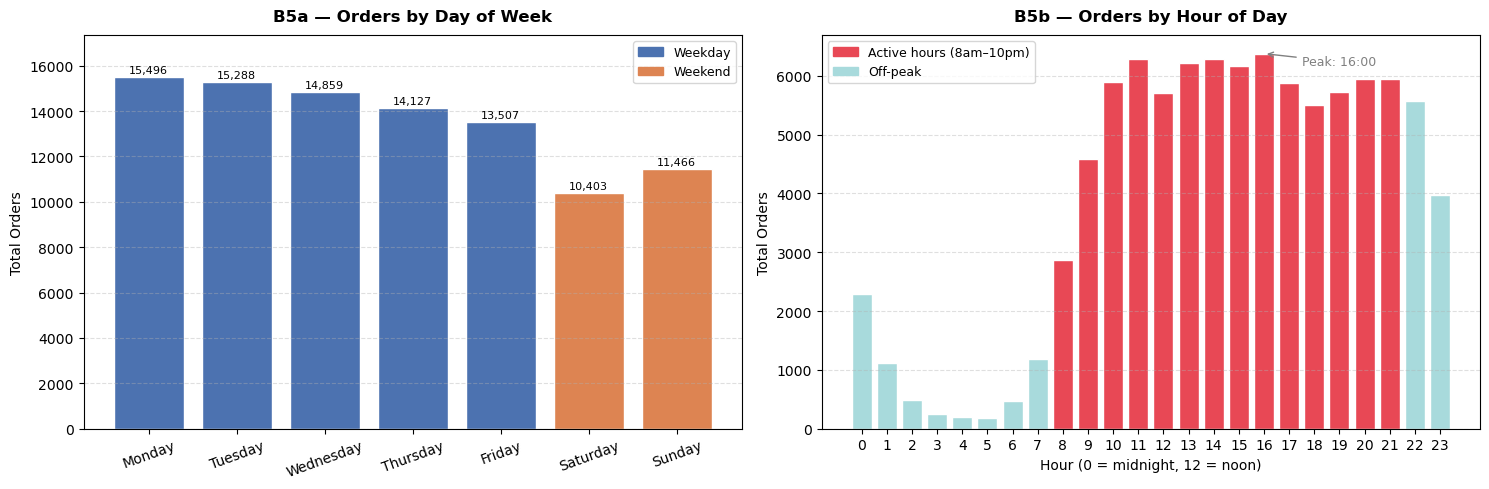

In [36]:
dow_pd  = dow_trend.select("day_name","purchase_dayofweek","total_orders").toPandas()
hour_pd = hour_trend.toPandas()

# Sort Mon→Sun
dow_pd["sort_key"] = dow_pd["purchase_dayofweek"].map({2:0,3:1,4:2,5:3,6:4,7:5,1:6})
dow_pd = dow_pd.sort_values("sort_key")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax1 = axes[0]
dow_colors = ["#DD8452" if d in ("Saturday","Sunday") else "#4C72B0" for d in dow_pd["day_name"]]
b = ax1.bar(dow_pd["day_name"], dow_pd["total_orders"], color=dow_colors, edgecolor="white")
for bar in b:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+80,
             f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=8)
ax1.set_title("B5a — Orders by Day of Week", fontsize=12, fontweight="bold", pad=10)
ax1.set_ylabel("Total Orders")
ax1.set_ylim(0, dow_pd["total_orders"].max()*1.12)
ax1.tick_params(axis="x", rotation=20)
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.legend(handles=[mpatches.Patch(color="#4C72B0",label="Weekday"),
                    mpatches.Patch(color="#DD8452",label="Weekend")], fontsize=9)

ax2 = axes[1]
h_colors = ["#E84855" if h in range(8,22) else "#A8DADC" for h in hour_pd["purchase_hour"]]
ax2.bar(hour_pd["purchase_hour"], hour_pd["total_orders"], color=h_colors, edgecolor="white", width=0.8)
peak_h = hour_pd.loc[hour_pd["total_orders"].idxmax(), "purchase_hour"]
ax2.annotate(f"Peak: {peak_h}:00",
    xy=(peak_h, hour_pd.loc[hour_pd["purchase_hour"]==peak_h,"total_orders"].values[0]),
    xytext=(peak_h+1.5, hour_pd["total_orders"].max()-200),
    arrowprops=dict(arrowstyle="->", color="gray"), fontsize=9, color="gray")
ax2.set_title("B5b — Orders by Hour of Day", fontsize=12, fontweight="bold", pad=10)
ax2.set_xlabel("Hour (0 = midnight, 12 = noon)"); ax2.set_ylabel("Total Orders")
ax2.set_xticks(range(0,24)); ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.legend(handles=[mpatches.Patch(color="#E84855",label="Active hours (8am–10pm)"),
                    mpatches.Patch(color="#A8DADC",label="Off-peak")], fontsize=9)

plt.tight_layout()
plt.savefig("output/B5_dow_hour_patterns.png", dpi=150, bbox_inches="tight"); plt.show()

### Save All Trend Outputs

In [37]:
monthly_orders.select("year_month","purchase_year","purchase_month","total_orders") \
    .coalesce(1).write.csv("output/monthly_order_trend", header=True, mode="overwrite")
top_categories.coalesce(1).write.csv("output/top_categories", header=True, mode="overwrite")
monthly_category_trend.select("year_month","purchase_year","purchase_month","category","order_count") \
    .coalesce(1).write.csv("output/monthly_category_trend", header=True, mode="overwrite")
annual_category.coalesce(1).write.csv("output/yoy_growth_by_category", header=True, mode="overwrite")
dow_trend.select("day_name","purchase_dayofweek","total_orders") \
    .coalesce(1).write.csv("output/dow_trend", header=True, mode="overwrite")
hour_trend.coalesce(1).write.csv("output/hour_trend", header=True, mode="overwrite")

print("All trend outputs saved to output/")

All trend outputs saved to output/


---
## Final Summary

In [38]:
total_custs  = df_clean.select("customer_unique_id").distinct().count()
rec_custs    = top5.select("customer_unique_id").distinct().count()
pair_count   = co_purchase_raw.count()
total_months = monthly_orders.count()
peak_row     = monthly_pd.loc[monthly_pd["total_orders"].idxmax()]

print("=" * 55)
print("NOTEBOOK 03 — RESULTS SUMMARY")
print("=" * 55)
print(f"\n[PART A — RECOMMENDATIONS]")
print(f"  Total customers           : {total_custs:,}")
print(f"  Customers with recs       : {rec_custs:,}")
print(f"  Co-purchase pairs         : {pair_count:,}")
print(f"\n[PART B — PURCHASING TRENDS]")
print(f"  Months analysed           : {total_months}")
print(f"  Peak month                : {peak_row['year_month']} ({int(peak_row['total_orders']):,} orders)")
print(f"  Categories tracked        : {df_clean.select('category').distinct().count()}")
print(f"\n[OUTPUTS]")
for f in ["recommendations","co_purchase_matrix","monthly_order_trend",
          "top_categories","monthly_category_trend","yoy_growth_by_category",
          "dow_trend","hour_trend"]:
    print(f"  output/{f}/")
print("=" * 55)

NOTEBOOK 03 — RESULTS SUMMARY

[PART A — RECOMMENDATIONS]
  Total customers           : 92,098
  Customers with recs       : 92,047
  Co-purchase pairs         : 242

[PART B — PURCHASING TRENDS]
  Months analysed           : 23
  Peak month                : 2017-11 (7,187 orders)
  Categories tracked        : 73

[OUTPUTS]
  output/recommendations/
  output/co_purchase_matrix/
  output/monthly_order_trend/
  output/top_categories/
  output/monthly_category_trend/
  output/yoy_growth_by_category/
  output/dow_trend/
  output/hour_trend/


In [40]:
spark.stop()